# Hospital Data Analysis

This notebook performs a basic, simple analysis of hospital.csv using numpy, pandas, and matplotlib.


In [21]:
## 1. Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make plots inline when run in Jupyter
%matplotlib inline


In [22]:
# 2. Read the CSV Dataset

path = 'hospital.csv'
df = pd.read_csv(path)
print('Loaded rows:', len(df))
df.head(5)


Loaded rows: 984


,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
0,1,45,Female,Heart Disease,Angioplasty,07-02-2024,12-02-2024,Kerala,2024,5,No,Recovered,4,Yes,15000
1,2,60,Male,Diabetes,Insulin Therapy,11-03-2023,14-03-2023,Goa,2023,3,Yes,Stable,3,No,2000
2,3,32,Female,Fractured Arm,X-Ray and Splint,02-01-2025,03-01-2025,Maharastra,2025,1,No,Recovered,5,Yes,500
3,4,75,Male,Stroke,CT Scan and Medication,30-12-2023,06-01-2024,Manipur,2023,7,Yes,Stable,2,No,10000
4,5,50,Female,Cancer,Surgery and Chemotherapy,10-05-2022,20-05-2022,Mizoram,2022,10,No,Recovered,4,No,25000


In [23]:
## 3. Clean the Dataset in Memory and Display Results

# Strip column names
df.columns = [c.strip() for c in df.columns]

# Fix types for numeric columns
for col in ['Age','Length_of_Stay','Satisfaction','Total_Cost']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Standardize yes/no fields
for col in ['Readmission','Insurance_Claimed']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.capitalize()
        df[col] = df[col].replace({'Yes':'Yes','No':'No','Nan':'No'})

# Parse dates
for col in ['Admission_Date','Discharge_Date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

# Show cleaning results
print('Missing values per column:')
print(df.isna().sum())

df.head(10)


Missing values per column:
Patient_ID           0
Age                  0
Gender               0
Condition            0
Medication           0
Admission_Date       0
Discharge_Date       0
Patient_State        0
Year_of_Admission    0
Length_of_Stay       0
Readmission          0
Outcome              0
Satisfaction         0
Insurance_Claimed    0
Total_Cost           0
dtype: int64


,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
0,1,45,Female,Heart Disease,Angioplasty,2024-02-07,2024-02-12,Kerala,2024,5,No,Recovered,4,Yes,15000
1,2,60,Male,Diabetes,Insulin Therapy,2023-03-11,2023-03-14,Goa,2023,3,Yes,Stable,3,No,2000
2,3,32,Female,Fractured Arm,X-Ray and Splint,2025-01-02,2025-01-03,Maharastra,2025,1,No,Recovered,5,Yes,500
3,4,75,Male,Stroke,CT Scan and Medication,2023-12-30,2024-01-06,Manipur,2023,7,Yes,Stable,2,No,10000
4,5,50,Female,Cancer,Surgery and Chemotherapy,2022-05-10,2022-05-20,Mizoram,2022,10,No,Recovered,4,No,25000
5,6,68,Male,Hypertension,Medication and Counseling,2025-06-27,2025-06-29,Sikkim,2025,2,No,Stable,4,Yes,1000
6,7,55,Female,Appendicitis,Appendectomy,2023-12-13,2023-12-17,Karnataka,2023,4,No,Recovered,3,No,8000
7,8,40,Male,Fractured Leg,Cast and Physical Therapy,2022-07-28,2022-08-03,Gujarat,2022,6,No,Recovered,4,Yes,3000
8,9,70,Female,Heart Attack,Cardiac Catheterization,2023-05-11,2023-05-19,Kerala,2023,8,Yes,Stable,2,No,18000
9,10,25,Male,Allergic Reaction,Epinephrine Injection,2023-04-25,2023-04-26,Kerala,2023,1,No,Recovered,5,No,100


In [24]:
## 4. Show Basic Dataset Information

print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)

# Show first 10 rows
df.head(10)


Shape: (984, 15)

Data types:
Patient_ID                    int64
Age                           int64
Gender                       object
Condition                    object
Medication                   object
Admission_Date       datetime64[ns]
Discharge_Date       datetime64[ns]
Patient_State                object
Year_of_Admission             int64
Length_of_Stay                int64
Readmission                  object
Outcome                      object
Satisfaction                  int64
Insurance_Claimed            object
Total_Cost                    int64
dtype: object


,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
0,1,45,Female,Heart Disease,Angioplasty,2024-02-07,2024-02-12,Kerala,2024,5,No,Recovered,4,Yes,15000
1,2,60,Male,Diabetes,Insulin Therapy,2023-03-11,2023-03-14,Goa,2023,3,Yes,Stable,3,No,2000
2,3,32,Female,Fractured Arm,X-Ray and Splint,2025-01-02,2025-01-03,Maharastra,2025,1,No,Recovered,5,Yes,500
3,4,75,Male,Stroke,CT Scan and Medication,2023-12-30,2024-01-06,Manipur,2023,7,Yes,Stable,2,No,10000
4,5,50,Female,Cancer,Surgery and Chemotherapy,2022-05-10,2022-05-20,Mizoram,2022,10,No,Recovered,4,No,25000
5,6,68,Male,Hypertension,Medication and Counseling,2025-06-27,2025-06-29,Sikkim,2025,2,No,Stable,4,Yes,1000
6,7,55,Female,Appendicitis,Appendectomy,2023-12-13,2023-12-17,Karnataka,2023,4,No,Recovered,3,No,8000
7,8,40,Male,Fractured Leg,Cast and Physical Therapy,2022-07-28,2022-08-03,Gujarat,2022,6,No,Recovered,4,Yes,3000
8,9,70,Female,Heart Attack,Cardiac Catheterization,2023-05-11,2023-05-19,Kerala,2023,8,Yes,Stable,2,No,18000
9,10,25,Male,Allergic Reaction,Epinephrine Injection,2023-04-25,2023-04-26,Kerala,2023,1,No,Recovered,5,No,100


In [25]:
## 5. Simple Analysis

# Financial: overall and by condition
if 'Total_Cost' in df.columns:
    total_cost_summary = df['Total_Cost'].describe()
    print('Total cost summary:\n', total_cost_summary)

    cost_by_condition = df.groupby('Condition')['Total_Cost'].mean().sort_values(ascending=False).head(10)
    print('\nTop 10 conditions by average cost:\n', cost_by_condition)

# Demographic: age and gender distributions
if 'Age' in df.columns:
    print('\nAge summary:\n', df['Age'].describe())

if 'Gender' in df.columns:
    gender_counts = df['Gender'].value_counts()
    print('\nGender counts:\n', gender_counts)

# Length of stay summary
if 'Length_of_Stay' in df.columns:
    print('\nLength of stay summary:\n', df['Length_of_Stay'].describe())
    los_by_condition = df.groupby('Condition')['Length_of_Stay'].mean().sort_values(ascending=False).head(10)
    print('\nTop 10 conditions by average length of stay:\n', los_by_condition)


Total cost summary:
 count      984.000000
mean      8367.479675
std       7761.990976
min        100.000000
25%       1000.000000
50%       6000.000000
75%      15000.000000
max      25000.000000
Name: Total_Cost, dtype: float64

Top 10 conditions by average cost:
 Condition
Cancer             25000.0
Prostate Cancer    20000.0
Heart Attack       18000.0
Heart Disease      15000.0
Childbirth         12000.0
Stroke             10000.0
Appendicitis        8000.0
Kidney Stones       6000.0
Osteoarthritis      4000.0
Fractured Leg       3000.0
Name: Total_Cost, dtype: float64

Age summary:
 count    984.000000
mean      53.754065
std       14.941135
min       25.000000
25%       45.000000
50%       55.000000
75%       65.000000
max       78.000000
Name: Age, dtype: float64

Gender counts:
 Gender
Female    524
Male      460
Name: count, dtype: int64

Length of stay summary:
 count    984.000000
mean      37.663618
std       19.595805
min        1.000000
25%       21.000000
50%       38.00

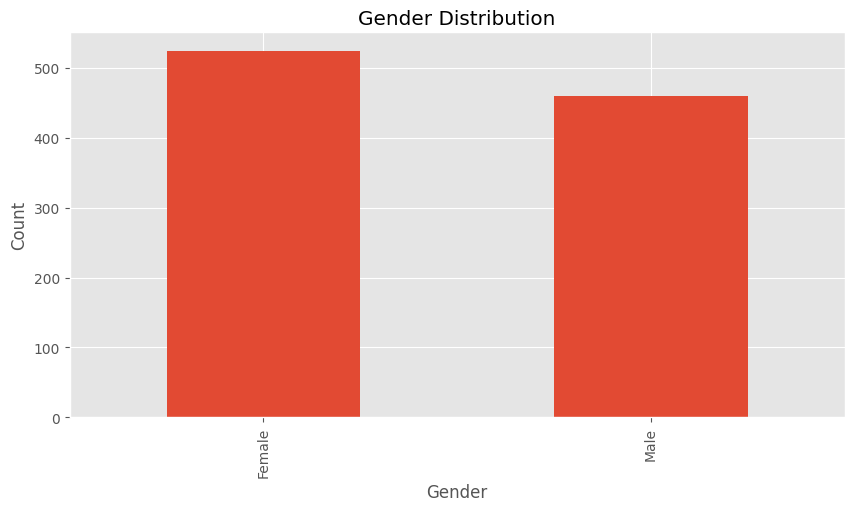

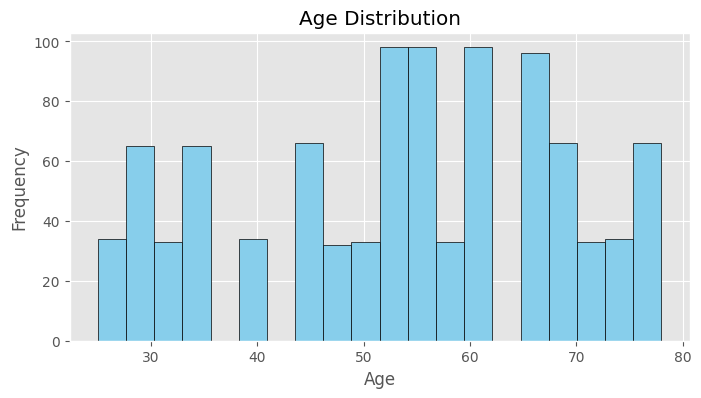

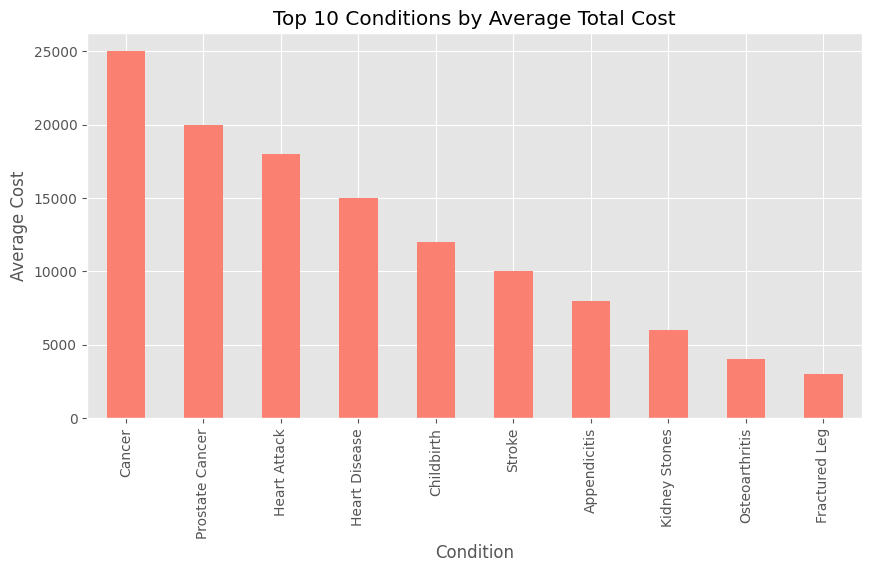

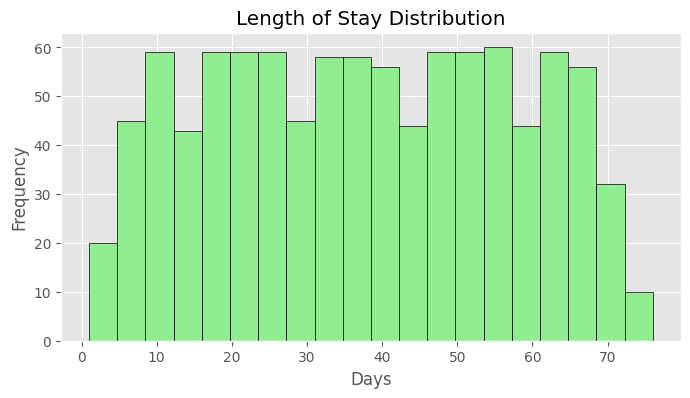

In [26]:
## 6. Visualize Analysis Summary with Matplotlib

plt.figure(figsize=(10,5))
# Gender distribution
if 'Gender' in df.columns:
    gender_counts.plot(kind='bar')
    plt.title('Gender Distribution')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.show()

# Age histogram
if 'Age' in df.columns:
    plt.figure(figsize=(8,4))
    plt.hist(df['Age'].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title('Age Distribution')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.show()

# Total cost by top conditions
if not cost_by_condition.empty:
    plt.figure(figsize=(10,5))
    cost_by_condition.plot(kind='bar', color='salmon')
    plt.title('Top 10 Conditions by Average Total Cost')
    plt.ylabel('Average Cost')
    plt.show()

# Length of stay histogram
if 'Length_of_Stay' in df.columns:
    plt.figure(figsize=(8,4))
    plt.hist(df['Length_of_Stay'].dropna(), bins=20, color='lightgreen', edgecolor='black')
    plt.title('Length of Stay Distribution')
    plt.xlabel('Days')
    plt.ylabel('Frequency')
    plt.show()
